In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

                Value
Date                 
2001-01-01  331770.42
2001-02-01  282305.52
2001-03-01  300016.76
2001-04-01  277521.79
2001-05-01  299747.31


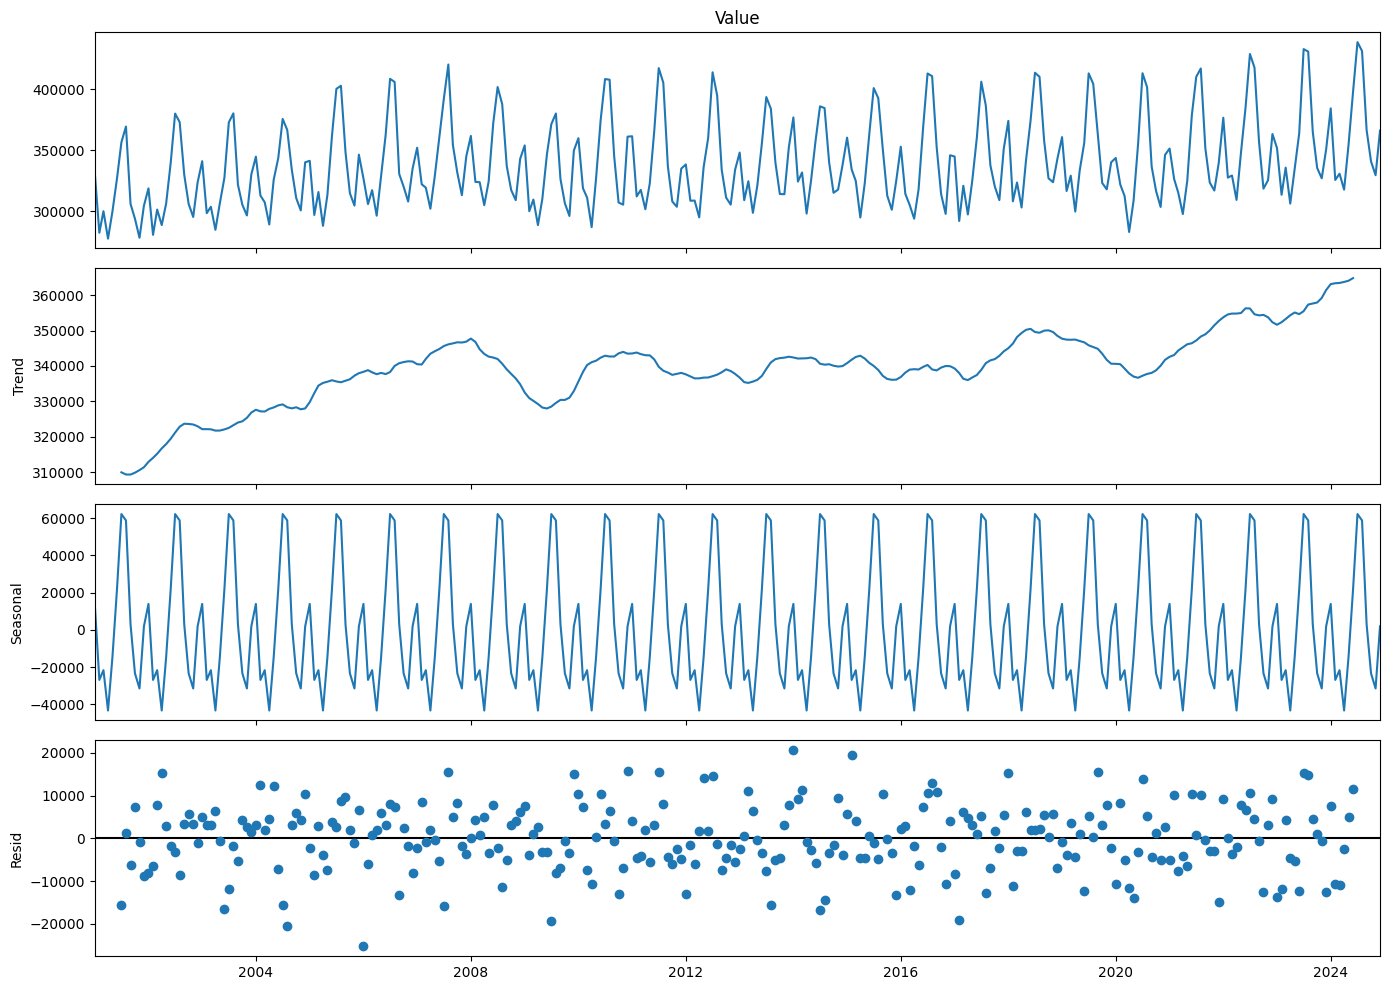

In [88]:
df=pd.read_csv("../data/raw/us_monthly_electricity.csv")
df['Date'] = pd.to_datetime(df['Date'])

mask = (
    (df['State'] == 'US Total') & 
    (df['Category'] == 'Electricity generation') &
    (df['Variable'] == 'Total Generation') &
    (df['Unit'] == 'GWh')
)

ts_data = df.loc[mask, ['Date', 'Value']].sort_values('Date').set_index('Date')
ts_data = ts_data[ts_data.index.year <= 2024]
ts_data = ts_data.asfreq('MS') 
decomposition = seasonal_decompose(ts_data['Value'], model='additive')
print(ts_data.head())
fig = decomposition.plot()
fig.set_size_inches(14, 10) 
plt.tight_layout()
plt.show()

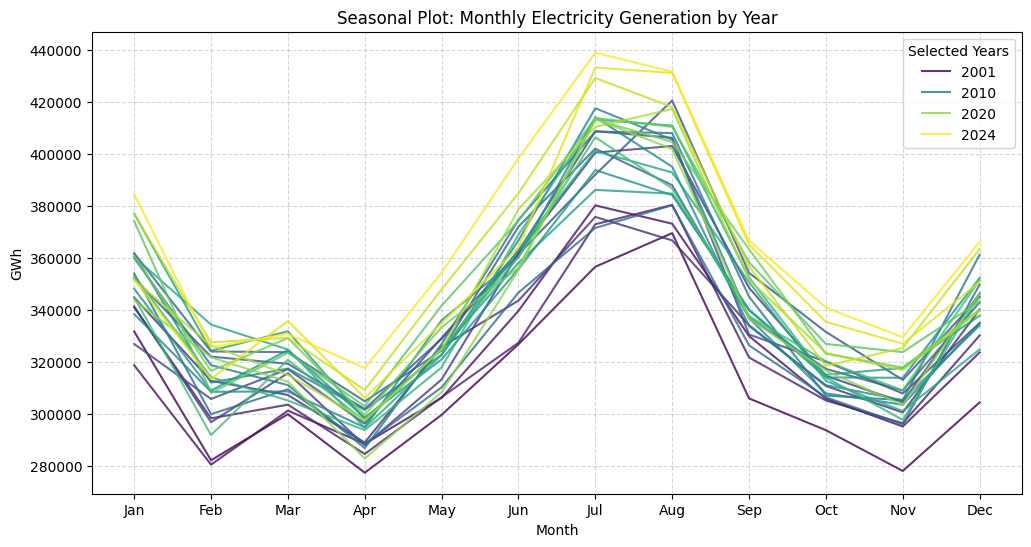

In [89]:
plt.figure(figsize=(12, 6))

ts_data['Year'] = ts_data.index.year
ts_data['Month'] = ts_data.index.month

pivot_df = ts_data.pivot(index='Month', columns='Year', values='Value')


colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_df.columns)))
for i, year in enumerate(pivot_df.columns):
  
    label = year if year in [2001, 2010, 2020, 2024] else ""
    plt.plot(pivot_df.index, pivot_df[year], color=colors[i], marker='', linewidth=1.5, alpha=0.8, label=label)

plt.title('Seasonal Plot: Monthly Electricity Generation by Year')
plt.ylabel('GWh')
plt.xlabel('Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Selected Years')
plt.grid(True, linestyle='--', alpha=0.5)


--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -2.1335757884715347
p-value: 0.23122962883667625
Critical Values:
	1%: -3.45453261164607
	5%: -2.8721859575020017
	10%: -2.572442854861866
Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.


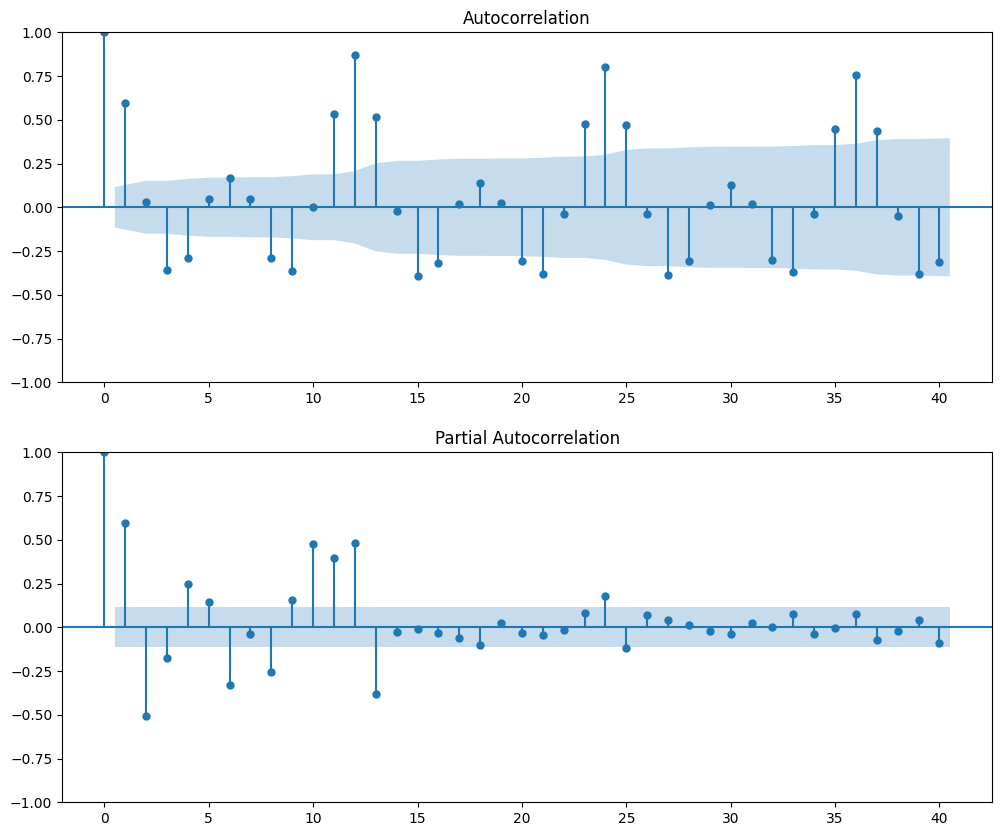

In [90]:
print("\n--- Augmented Dickey-Fuller Test Results ---")
result = adfuller(ts_data['Value'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# 3. ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_data['Value'], ax=ax1, lags=40);
plot_pacf(ts_data['Value'], ax=ax2, lags=40);


ADF Statistic: -5.122649669529774
p-value: 1.2620984597081788e-05
Critical Values:
	1%: -3.4554613060274972
	5%: -2.8725931472675046
	10%: -2.5726600403359887
Result: The series is Stationary (Reject Null Hypothesis)


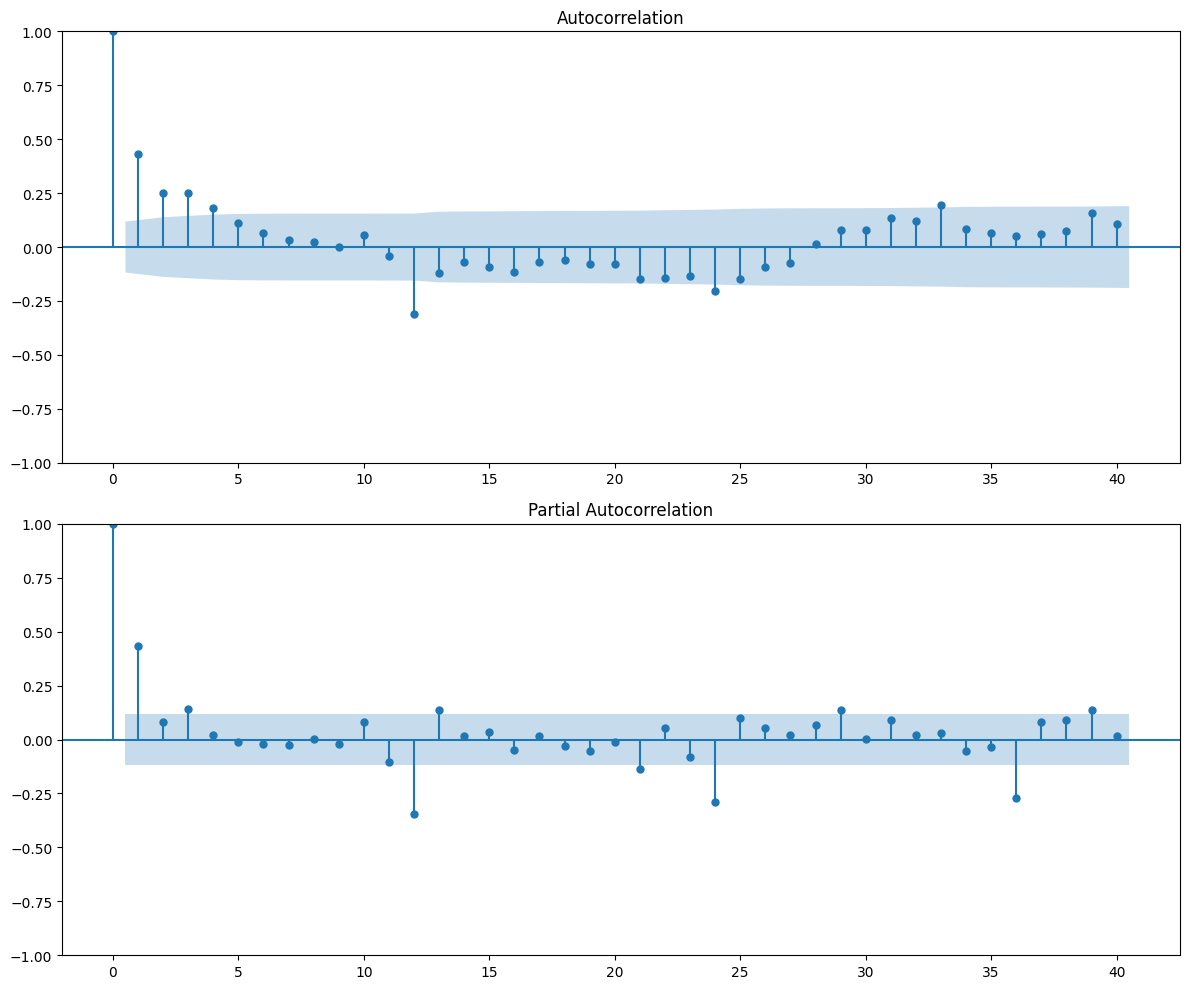

               Value  Year  Month
Date                             
2002-01-01 -12974.00  2002      1
2002-02-01  -1679.02  2002      2
2002-03-01   1344.63  2002      3
2002-04-01  11101.43  2002      4
2002-05-01   6529.59  2002      5


In [91]:
ts_seasonal_diff = ts_data.copy()
ts_seasonal_diff['Value'] = ts_data['Value'].diff(12)
ts_seasonal_diff = ts_seasonal_diff.dropna()

# Ora puoi accedere con ts_seasonal_diff['Value']
adf_test_final = adfuller(ts_seasonal_diff['Value'])
print(f'ADF Statistic: {adf_test_final[0]}')
print(f'p-value: {adf_test_final[1]}')
print('Critical Values:')
for key, value in adf_test_final[4].items():
    print(f'\t{key}: {value}')

if adf_test_final[1] <= 0.05:
    print("Result: The series is Stationary (Reject Null Hypothesis)")
else:
    print("Result: The series is Non-Stationary (Fail to reject Null Hypothesis). Differencing is likely needed.")

# ACF and PACF Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(ts_seasonal_diff['Value'], ax=ax1, lags=40)
plot_pacf(ts_seasonal_diff['Value'], ax=ax2, lags=40)
plt.tight_layout()
plt.show()

print(ts_seasonal_diff.head())

Training data: dal 2001-01-01 al 2022-12-01
Test data: dal 2023-01-01 al 2024-12-01
Addestramento del modello in corso...
Modello addestrato!
                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                  264
Model:             SARIMAX(1, 0, 0)x(1, 1, 0, 12)   Log Likelihood               -2558.112
Date:                            Fri, 12 Dec 2025   AIC                           5122.223
Time:                                    17:23:07   BIC                           5132.653
Sample:                                01-01-2001   HQIC                          5126.426
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

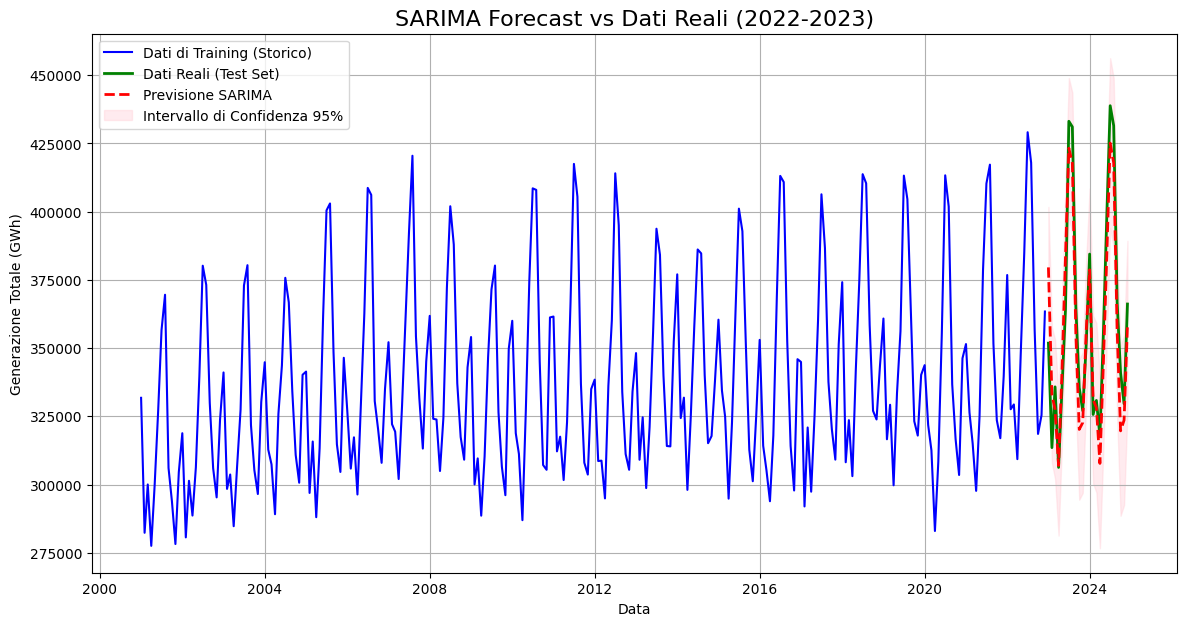


Errore Medio Assoluto Percentuale (MAPE): 3.02%
Significa che il modello sbaglia in media del 3.02%


In [92]:
train_data = ts_data.iloc[:-24]
test_data = ts_data.iloc[-24:]

print(f"Training data: dal {train_data.index.min().date()} al {train_data.index.max().date()}")
print(f"Test data: dal {test_data.index.min().date()} al {test_data.index.max().date()}")

my_order = (1, 0, 0)              # (p, d, q) - Parte non stagionale
my_seasonal_order = (1, 1, 0, 12) # (P, D, Q, m) - Parte stagionale (m=12 mesi)

model = SARIMAX(train_data['Value'], 
                order=my_order, 
                seasonal_order=my_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)


print("Addestramento del modello in corso...")
model_fit = model.fit(disp=False)
print("Modello addestrato!")
print(model_fit.summary())

forecast = model_fit.get_forecast(steps=len(test_data))
predicted_values = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data['Value'], label='Dati di Training (Storico)', color='blue')
plt.plot(test_data.index, test_data['Value'], label='Dati Reali (Test Set)', color='green', linewidth=2)
plt.plot(test_data.index, predicted_values, label='Previsione SARIMA', color='red', linestyle='--', linewidth=2)
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Intervallo di Confidenza 95%')

plt.title('SARIMA Forecast vs Dati Reali (2022-2023)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Generazione Totale (GWh)')
plt.legend()
plt.grid(True)
plt.show()

mape = mean_absolute_percentage_error(test_data['Value'], predicted_values)
print(f"\nErrore Medio Assoluto Percentuale (MAPE): {mape:.2%}")
print(f"Significa che il modello sbaglia in media del {mape:.2%}")

Si riaddestra usando tutti i dati stavolta

Addestramento del modello su tutti i dati...
Modello addestrato!

=== Previsioni Future ===
            Predicted_Value    Lower_Bound    Upper_Bound
Date                                                     
2025-01-01    377133.473028  354196.706943  400070.239113
2025-02-01    323572.236378  298000.351299  349144.121457
2025-03-01    333971.262709  307799.152013  360143.373405
2025-04-01    313960.401514  287644.520382  340276.282647
2025-05-01    347201.524796  320850.830017  373552.219576
2025-06-01    385301.958034  358942.811479  411661.104589
2025-07-01    436704.387101  410343.187415  463065.586786
2025-08-01    431380.301176  405018.602663  457741.999689
2025-09-01    366092.904947  339731.085235  392454.724660
2025-10-01    338852.730976  312490.881816  365214.580136
2025-11-01    328602.354659  302240.498343  354964.210974
2025-12-01    360268.930087  333907.072033  386630.788140
2026-01-01    379935.066276  350011.770526  409858.362026
2026-02-01    324376.079608  293649.72

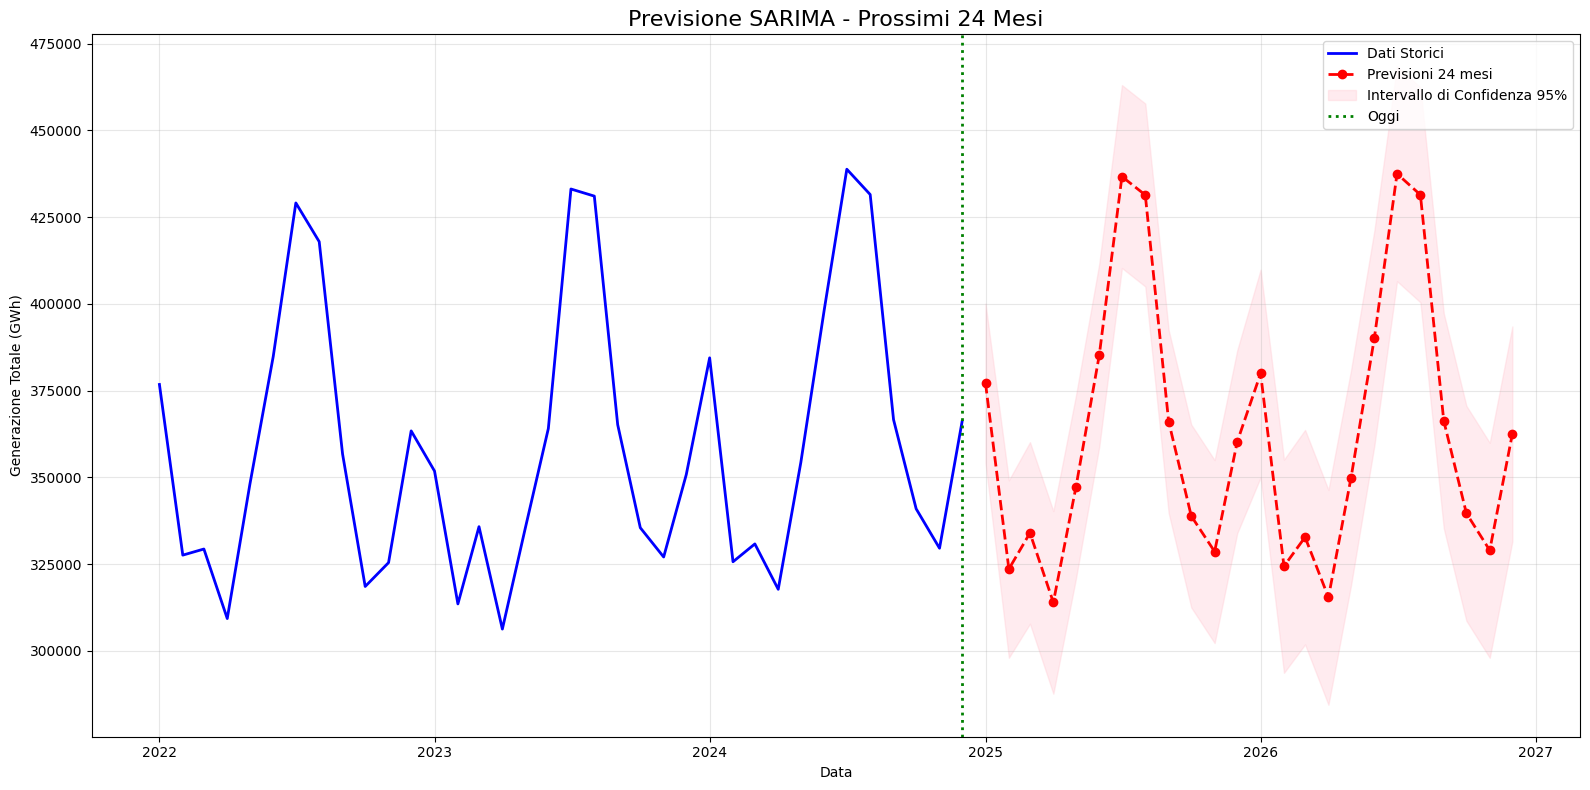

In [95]:
full_data = ts_data['Value']

my_order = (1, 0, 0)
my_seasonal_order = (1, 1, 0, 12)

model_full = SARIMAX(full_data, 
                     order=my_order, 
                     seasonal_order=my_seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

print("Addestramento del modello su tutti i dati...")
model_full_fit = model_full.fit(disp=False)
print("Modello addestrato!")

n_months = 24  # Modifica questo per prevedere più o meno mesi

forecast_future = model_full_fit.get_forecast(steps=n_months)
predicted_future = forecast_future.predicted_mean
conf_int_future = forecast_future.conf_int()

last_date = ts_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                             periods=n_months, 
                             freq='MS') 

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Value': predicted_future.values,
    'Lower_Bound': conf_int_future.iloc[:, 0].values,
    'Upper_Bound': conf_int_future.iloc[:, 1].values
})
forecast_df.set_index('Date', inplace=True)

print("\n=== Previsioni Future ===")
print(forecast_df)

plt.figure(figsize=(16, 8))
historical = ts_data.iloc[-36:]
plt.plot(historical.index, historical['Value'], 
         label='Dati Storici', color='blue', linewidth=2)
plt.plot(future_dates, predicted_future, 
         label=f'Previsioni {n_months} mesi', 
         color='red', linestyle='--', linewidth=2, marker='o')
plt.fill_between(future_dates, 
                 conf_int_future.iloc[:, 0], 
                 conf_int_future.iloc[:, 1], 
                 color='pink', alpha=0.3, 
                 label='Intervallo di Confidenza 95%')

plt.axvline(x=ts_data.index[-1], color='green', 
            linestyle=':', linewidth=2, label='Oggi')
plt.title(f'Previsione SARIMA - Prossimi {n_months} Mesi', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Generazione Totale (GWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

